# BNP Paribas Personal Finance - Fraud Detection

### Summary

Fraud is a major problem for merchants. Criminals use a wide variety of methods to attack organizations across systems, channels, processes and products. The development of fraud detection methods is thus of crucial importance. Fraud detection is a challenging problem because fraudsters make their best efforts to make their behaviour look legitimate. Another difficulty is that the number of legitimate records is far greater than the number of fraudulent cases.

### Dataset

The dataset contains a list of financed purchases, in which there is information about the content of the baskets. For each line of the dataset there are 147 columns, in which 144 are grouped in 6 categories:

 - item
 - cash price
 - make
 - model
 - goods code
 - Nbr of product purchased

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from skopt import BayesSearchCV

## Dataset

We read the dataset using pandas and set index to col `ID` then we proceed to retrieve specific information from the dataframe including the number of entries and dtype, missing and unique values from each column

In [2]:
df = pd.read_csv("../data/fraud/FraudeCanastas.csv", index_col="ID")

df.head()

,APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90,AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE 2ND GENERATI,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE 2ND,AUDIO ACCESSORIES | APPLE | 2021 APPLE AIRPODS WITH MAGSAFE CHARGING CASE 3RD,AUDIO ACCESSORIES | APPLE | AIRPODS PRO,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX NOISE CANCELLING WIRELESS BLUETO,...,WOMEN S NIGHTWEAR | ANYDAY RETAILER | ANYDAY RETAILER LEOPARD PRINT JERSEY PY,WOMEN S NIGHTWEAR | RETAILER | RETAILER CLEO VELOUR JOGGER LOUNGE PANT,WOMEN S NIGHTWEAR | SOSANDAR | SOSANDAR ZEBRA PRINT PYJAMA BOTTOMS BLACK 10,Nb_of_items,total_of_items,costo_total,costo_medio_item,costo_item_max,costo_item_min,fraud_flag
ID,,,,,,,,,,,,,,,,,,,,,
130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2,2,1299,649.500000,1299,0.0,1.0
195,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3,3,4119,1373.000000,2470,0.0,1.0
217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2,2,2806,1403.000000,2799,7.0,1.0
552,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2,2,1206,603.000000,1199,7.0,1.0
854,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,19,27,1807,66.925926,195,4.0,1.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 9319 entries, 130 to 49022
Columns: 2456 entries, APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90 to fraud_flag
dtypes: float64(2452), int64(4)
memory usage: 174.7 MB


In [4]:
def describe(df):

    unique = []
    for col in df.columns:
        unique.append(df[col].unique())
    unique_series = pd.Series(unique, index=df.columns)
    return pd.concat(
        [
            df.dtypes,
            df.isna().sum(),
            round(df.isna().sum() / len(df) * 100, 1),
            df.nunique(),
            unique_series,
        ],
        axis=1,
        keys=["dtype", "missing", "%null", "nunique", "unique"],
    )


describe(df)

,dtype,missing,%null,nunique,unique
APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90,float64,0,0.0,2,"[0.0, 1000.0]"
AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H,float64,0,0.0,2,"[0.0, 20.0]"
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE,float64,0,0.0,8,"[0.0, 125.0, 119.0, 120.0, 500.0, 129.0, 109.0..."
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE 2ND GENERATI,float64,0,0.0,8,"[0.0, 109.0, 100.0, 105.0, 104.0, 99.0, 119.0,..."
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE,float64,0,0.0,4,"[0.0, 149.0, 158.0, 168.0]"
...,...,...,...,...,...
costo_total,int64,0,0.0,1639,"[1299, 4119, 2806, 1206, 1807, 1263, 942, 1199..."
costo_medio_item,float64,0,0.0,2034,"[649.5, 1373.0, 1403.0, 603.0, 66.925925925925..."
costo_item_max,int64,0,0.0,540,"[1299, 2470, 2799, 1199, 195, 280, 938, 929, 1..."
costo_item_min,float64,0,0.0,528,"[0.0, 7.0, 4.0, 1249.0, 25.0, 2470.0, 999.0, 1..."


## Data Preprocessing

Identification of three parts of the dataset `basket`, `total` and `fraud` or `label` we separate this columns in dataframes which will be processed differently.

 - basket: one-hot and tf-idf vectorizer
 - total: min-max-scaler
 - fraud: target variable was left as it is

In [5]:
basket = df.iloc[:, :-7].astype(int)
total = df.iloc[:, -7:-1]
fraud = df.iloc[:, -1]

In [6]:
encoder = OneHotEncoder(drop="first", sparse_output=False)
one_hot_basket = encoder.fit_transform(basket)

one_hot_basket_df = pd.DataFrame(
    one_hot_basket,
    index=basket.index,
    columns=encoder.get_feature_names_out(),
).astype(int)

describe(one_hot_basket_df)

,dtype,missing,%null,nunique,unique
APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90_1000,int64,0,0.0,2,"[0, 1]"
AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H_20,int64,0,0.0,2,"[0, 1]"
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE_109,int64,0,0.0,2,"[0, 1]"
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE_119,int64,0,0.0,2,"[0, 1]"
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE_120,int64,0,0.0,2,"[0, 1]"
...,...,...,...,...,...
WOMEN S FOOTWEAR | ROCKET DOG | ROCKET DOG CHEERY CANVAS TRAINERS WHITE 3_38,int64,0,0.0,2,"[0, 1]"
WOMEN S FOOTWEAR | UGG | UGG CLASSIC MINI II SHORT SHEEPSKIN BOOTS CHESTNUT_145,int64,0,0.0,2,"[0, 1]"
WOMEN S NIGHTWEAR | ANYDAY RETAILER | ANYDAY RETAILER LEOPARD PRINT JERSEY PY_28,int64,0,0.0,2,"[0, 1]"
WOMEN S NIGHTWEAR | RETAILER | RETAILER CLEO VELOUR JOGGER LOUNGE PANT_18,int64,0,0.0,2,"[0, 1]"


In [7]:
vectorizer = TfidfTransformer()
vectorized_basket = vectorizer.fit_transform(one_hot_basket_df)

vectorized_basket_df = pd.DataFrame(
    vectorized_basket.todense(),  # type: ignore
    index=basket.index,
    columns=vectorizer.get_feature_names_out(),
)

describe(vectorized_basket_df)

,dtype,missing,%null,nunique,unique
APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90_1000,float64,0,0.0,2,"[0.0, 0.7071067811865475]"
AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H_20,float64,0,0.0,2,"[0.0, 0.7244356844669503]"
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE_109,float64,0,0.0,3,"[0.0, 0.7886436942612468, 0.7684392618067257]"
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE_119,float64,0,0.0,2,"[0.0, 0.9120216669061357]"
AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE_120,float64,0,0.0,3,"[0.0, 0.6182557237683995, 0.583472366450739]"
...,...,...,...,...,...
WOMEN S FOOTWEAR | ROCKET DOG | ROCKET DOG CHEERY CANVAS TRAINERS WHITE 3_38,float64,0,0.0,2,"[0.0, 0.2791597618386579]"
WOMEN S FOOTWEAR | UGG | UGG CLASSIC MINI II SHORT SHEEPSKIN BOOTS CHESTNUT_145,float64,0,0.0,2,"[0.0, 0.3694019711388358]"
WOMEN S NIGHTWEAR | ANYDAY RETAILER | ANYDAY RETAILER LEOPARD PRINT JERSEY PY_28,float64,0,0.0,2,"[0.0, 0.3278908480268799]"
WOMEN S NIGHTWEAR | RETAILER | RETAILER CLEO VELOUR JOGGER LOUNGE PANT_18,float64,0,0.0,2,"[0.0, 0.29301947952106516]"


In [8]:
scaler = MinMaxScaler()
total_scaled = scaler.fit_transform(total)
total_scaled_df = pd.DataFrame(
    total_scaled,
    index=total.index,
    columns=scaler.get_feature_names_out(),
)
describe(total_scaled_df)

,dtype,missing,%null,nunique,unique
Nb_of_items,float64,0,0.0,28,"[0.02702702702702703, 0.05405405405405406, 0.4..."
total_of_items,float64,0,0.0,34,"[0.023255813953488372, 0.046511627906976744, 0..."
costo_total,float64,0,0.0,1639,"[0.044385993753082366, 0.16028275521946408, 0...."
costo_medio_item,float64,0,0.0,2034,"[0.03045913215081366, 0.0667113773193651, 0.06..."
costo_item_max,float64,0,0.0,540,"[0.0588353716845337, 0.11777140268760382, 0.13..."
costo_item_min,float64,0,0.0,528,"[0.0, 0.00035001750087504374, 0.00020001000050..."


In [ ]:
processed_df = vectorized_basket_df.join(total_scaled_df)
processed_df.head()

,APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90_1000,AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H_20,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE_109,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE_119,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE_120,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE_125,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE_129,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE_130,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE_500,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE 2ND GENERATI_99,...,WOMEN S FOOTWEAR | UGG | UGG CLASSIC MINI II SHORT SHEEPSKIN BOOTS CHESTNUT_145,WOMEN S NIGHTWEAR | ANYDAY RETAILER | ANYDAY RETAILER LEOPARD PRINT JERSEY PY_28,WOMEN S NIGHTWEAR | RETAILER | RETAILER CLEO VELOUR JOGGER LOUNGE PANT_18,WOMEN S NIGHTWEAR | SOSANDAR | SOSANDAR ZEBRA PRINT PYJAMA BOTTOMS BLACK 10_26,Nb_of_items,total_of_items,costo_total,costo_medio_item,costo_item_max,costo_item_min
ID,,,,,,,,,,,,,,,,,,,,,
130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.027027,0.023256,0.044386,0.030459,0.058835,0.00000
195,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.054054,0.046512,0.160283,0.066711,0.117771,0.00000
217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.027027,0.023256,0.106321,0.068215,0.134330,0.00035
552,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.027027,0.023256,0.040564,0.028129,0.053802,0.00035
854,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.486486,0.604651,0.065264,0.001268,0.003271,0.00020


## Dataset split

Dataset is splitted train and test with a percentage of 80% and 20% of the total records respectively

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    processed_df,
    fraud,
    test_size=0.20,
    shuffle=True,
    random_state=42,
    stratify=fraud,
)

len(X_train), len(X_test), len(y_train), len(y_test)

(7455, 1864, 7455, 1864)

## Class weight

Since we are dealing with a unbalanced dataset we must estimate the weights of each class this is done with the following formula.

$$
weights = \frac{N}{classes * freq}
$$

 - N is the number of samples
 - classes are the number of classes
 - freq is the bincount or frequency of class i

In [11]:
class_weights = compute_class_weight(
    y=fraud, class_weight="balanced", classes=np.unique(y_train)
)

np.unique(y_train), class_weights

(array([0., 1.]), array([0.5824375 , 3.53260045]))

## Perceptron

The first model, perceptron, will work as a baseline. For this model BayesSearch is used and the hyper-parameters we try to find are: `penalty`, `alpha`, `tol`.

In [12]:
from skopt.space import Categorical, Real

params = {
    "penalty": Categorical([None, "l2"]),
    "alpha": Real(1e-9, 5e-2),
    "tol": Real(1e-9, 5e-2),
}

bayes_perceptron = BayesSearchCV(
    Perceptron(
        class_weight={0: 0.5824375, 1: 3.53260045},  # type: ignore
        max_iter=1500,
        n_jobs=-1,
    ),
    params,
    n_iter=50,
    scoring="accuracy",
    verbose=1,
)

bayes_perceptron.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

,estimator,"Perceptron(cl...00, n_jobs=-1)"
,search_spaces,"{'alpha': Real(low=1e-0...m='normalize'), 'penalty': Categorical(c...), prior=None), 'tol': Real(low=1e-0...m='normalize')}"
,optimizer_kwargs,None
,n_iter,50
,scoring,'accuracy'
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,None


This are the best parameters for the perceptron

In [13]:
print(f"Best Params: {bayes_perceptron.best_params_}")  # type: ignore

Best Params: OrderedDict({'alpha': 0.025133574904859096, 'penalty': None, 'tol': 0.04288213398171368})


The metrics for the model using train and test to compare if it was over-fitted or under-fitted

In [14]:
print(f"Score: {bayes_perceptron.score(X_train, y_train)}")
y_pred = bayes_perceptron.predict(X_train)
print(classification_report(y_train, y_pred))

Score: 0.8662642521797451
              precision    recall  f1-score   support

         0.0       0.93      0.91      0.92      6400
         1.0       0.52      0.60      0.56      1055

    accuracy                           0.87      7455
   macro avg       0.73      0.75      0.74      7455
weighted avg       0.87      0.87      0.87      7455



In [15]:
print(f"Score: {bayes_perceptron.score(X_test, y_test)}")
y_pred = bayes_perceptron.predict(X_test)
print(classification_report(y_test, y_pred))

Score: 0.8347639484978541
              precision    recall  f1-score   support

         0.0       0.91      0.90      0.90      1600
         1.0       0.42      0.46      0.44       264

    accuracy                           0.83      1864
   macro avg       0.67      0.68      0.67      1864
weighted avg       0.84      0.83      0.84      1864



The confusion matrix to review type I and II Errors.

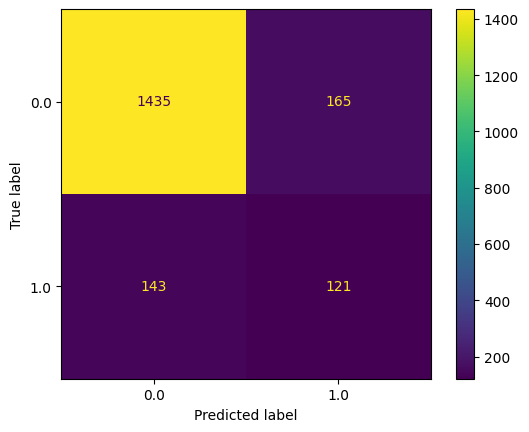

In [16]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=np.unique(y_train))

And the ROC curve

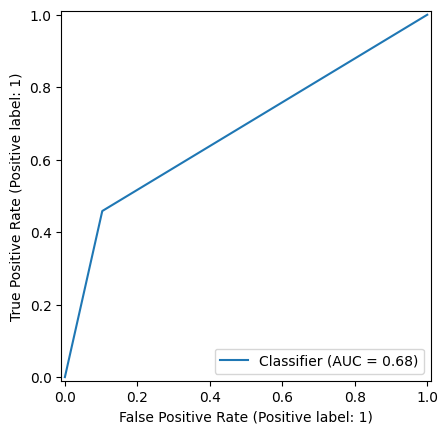

In [17]:
RocCurveDisplay.from_predictions(y_test, y_pred)

## Logistic Regression

The parameters that were tuned are `C` and `l1_ratio`.

In [18]:
from skopt.space import Real

params = {
    "C": Real(1e-3, 1e3),
    "l1_ratio": Real(0.0, 1.0),
}

bayes_log_regression = BayesSearchCV(
    LogisticRegression(
        class_weight={0: 0.5824375, 1: 3.53260045},
        solver="saga",
        max_iter=1500,
        tol=0.01,
    ),
    params,
    n_iter=50,
    scoring="accuracy",
    verbose=1,
)

bayes_log_regression.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

,estimator,"LogisticRegre...ga', tol=0.01)"
,search_spaces,"{'C': Real(low=0.00...m='normalize'), 'l1_ratio': Real(low=0.0,...m='normalize')}"
,optimizer_kwargs,None
,n_iter,50
,scoring,'accuracy'
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,None


In [19]:
print(f"Best Params: {bayes_log_regression.best_params_}")  # type: ignore

Best Params: OrderedDict({'C': 332.23697105240575, 'l1_ratio': 0.9188207481355142})


In [20]:
print(f"Score: {bayes_log_regression.score(X_train, y_train)}")
y_pred = bayes_log_regression.predict(X_train)
print(classification_report(y_train, y_pred))

Score: 0.8124748490945674
              precision    recall  f1-score   support

         0.0       0.98      0.79      0.88      6400
         1.0       0.42      0.92      0.58      1055

    accuracy                           0.81      7455
   macro avg       0.70      0.86      0.73      7455
weighted avg       0.90      0.81      0.84      7455



In [21]:
print(f"Score: {bayes_log_regression.score(X_test, y_test)}")
y_pred = bayes_log_regression.predict(X_test)
print(classification_report(y_test, y_pred))

Score: 0.7752145922746781
              precision    recall  f1-score   support

         0.0       0.95      0.78      0.86      1600
         1.0       0.36      0.75      0.49       264

    accuracy                           0.78      1864
   macro avg       0.65      0.76      0.67      1864
weighted avg       0.87      0.78      0.80      1864



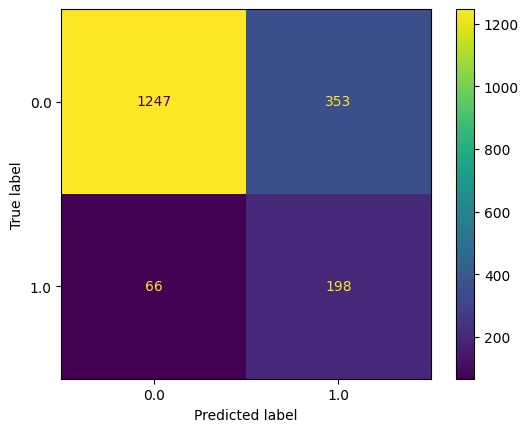

In [22]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=np.unique(y_train))

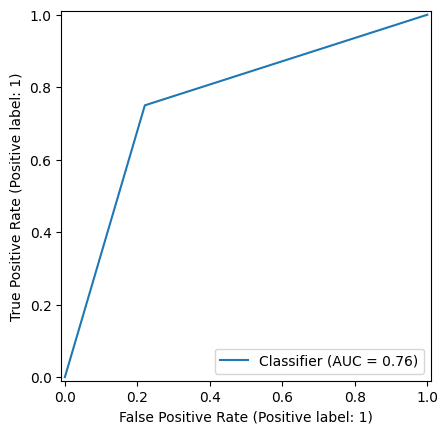

In [23]:
RocCurveDisplay.from_predictions(y_test, y_pred)

## Random Forest

The parameters that were tuned are `n_estimators`, `max_depth`, `min_samples_leaf`, `min_samples_split` and `max_leaf_nodes`

In [90]:
from skopt.space import Integer

params = {
    "n_estimators": Integer(1, 500),
    "max_depth": Integer(1, 2500),
    "min_samples_leaf": Integer(1, 20),
    "min_samples_split": Integer(2, 20),
    "max_leaf_nodes": Integer(2, 500),
}

bayes_tree = BayesSearchCV(
    RandomForestClassifier(
        criterion="entropy",
        class_weight={0: 0.5824375, 1: 3.53260045},
        n_jobs=-1,
    ),
    params,
    n_iter=50,
    scoring="accuracy",
    verbose=1,
)

bayes_tree.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

,estimator,"RandomForestC...y', n_jobs=-1)"
,search_spaces,"{'max_depth': Integer(low=1...m='normalize'), 'max_leaf_nodes': Integer(low=2...m='normalize'), 'min_samples_leaf': Integer(low=1...m='normalize'), 'min_samples_split': Integer(low=2...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,50
,scoring,'accuracy'
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,None


In [91]:
print(f"Best Params: {bayes_tree.best_params_}")  # type: ignore

Best Params: OrderedDict({'max_depth': 1443, 'max_leaf_nodes': 279, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 303})


In [92]:
print(f"Score: {bayes_tree.score(X_train, y_train)}")
y_pred = bayes_tree.predict(X_train)
print(classification_report(y_train, y_pred))

Score: 0.857813547954393
              precision    recall  f1-score   support

         0.0       0.96      0.87      0.91      6400
         1.0       0.50      0.79      0.61      1055

    accuracy                           0.86      7455
   macro avg       0.73      0.83      0.76      7455
weighted avg       0.90      0.86      0.87      7455



In [93]:
print(f"Score: {bayes_tree.score(X_test, y_test)}")
y_pred = bayes_tree.predict(X_test)
print(classification_report(y_test, y_pred))

Score: 0.8159871244635193
              precision    recall  f1-score   support

         0.0       0.93      0.85      0.89      1600
         1.0       0.40      0.60      0.48       264

    accuracy                           0.82      1864
   macro avg       0.66      0.73      0.68      1864
weighted avg       0.85      0.82      0.83      1864



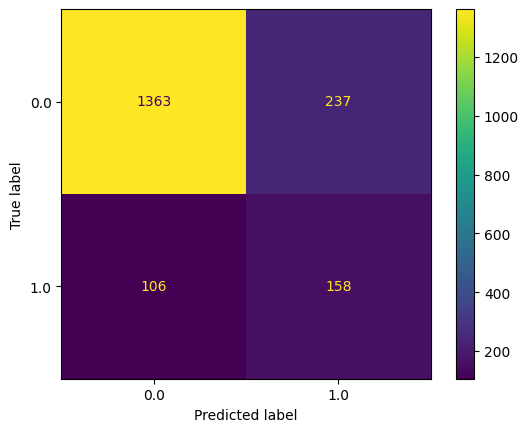

In [94]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=np.unique(y_train))

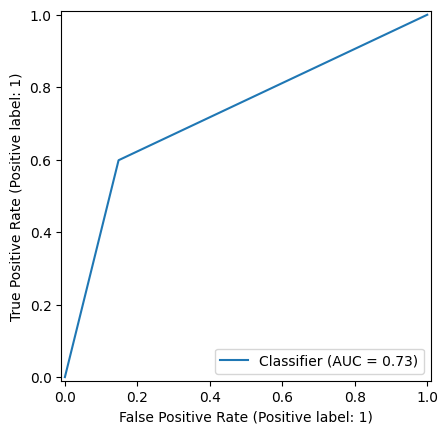

In [95]:
RocCurveDisplay.from_predictions(y_test, y_pred)

## Conclusion

The metrics precision, recall, f1-score and accuracy of the test dataset from the trained models are in the table below.


| Model                | Class | Precision | Recall | F1-score | Accuracy |
|----------------------|-------|-----------|--------|----------|----------|
| Perceptron           | 1.0   | 0.42      | 0.46   | 0.44     | 0.83     |
| Logistic Regression  | 1.0   | 0.36      | 0.75   | 0.49     | 0.78     |
| Random Forest        | 1.0   | 0.40      | 0.60   | 0.48     | 0.82     |




 - The logistic regression is the selected model because the highest recall score.
 - For the fraud domain the cost of not detecting a true fraud is higher that the other errors at the cost of precision which this cases can be checked manually.
 - Random Forest would be a second selection because if offers a higher accuracy that logistic regresion and higher recall than perceptron.
 - For random forest and perceptron we would risk the misclassification of true positives for false negatives which is the type of error that affect us the most.